In [15]:
from Configurations.imports import *

In [16]:
# creation of the dataset
x = np.linspace(start=-5.0, stop=5.0, num=100)
y = np.sqrt(10 ** 2 - x ** 2)

In [17]:
x = np.hstack([x,-x])
y = np.hstack([y, -y])

In [18]:
x1 = np.linspace(start=-5.0, stop=5.0, num=100)
y1= np.sqrt(5 ** 2 - x1 ** 2)

In [19]:
x1 = np.hstack([x1,-x1])
y1 = np.hstack([y1, -y1])

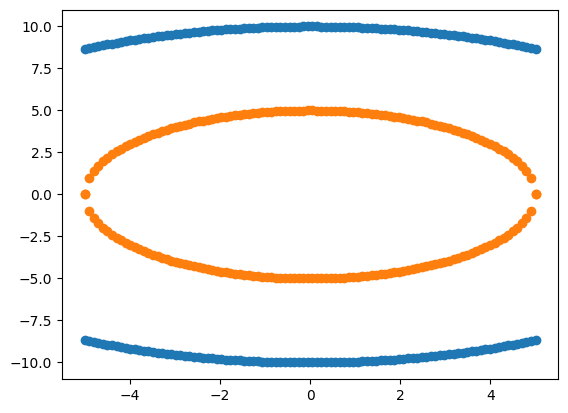

In [20]:
plt.scatter(x,y)
plt.scatter(x1,y1)

In [ ]:
# df1 = pd.DataFrame(np.vstack([y,x]).T, columns=["x1","x2"])
# df1["Y"] = 0

# df2 = pd.DataFrame(np.vstack([y1,x1]).T, columns=["x1","x2"])
# df2["Y"] = 1


In [41]:
df.drop("index", axis=1, inplace=True)

In [42]:
df

,x1,x2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0
...,...,...,...
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1


In [43]:
X = df.iloc[:,:2]
y = df.iloc[:,2]

In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y)

In [ ]:
# Hyper parameter tuning
param_grid = {
    "C":[0.1, 1, 10, 100, 1000],
    "gamma":[0.1, 0.01, 0.001, 0.0001],
    "kernel":["rbf","linear","poly"]
}

In [51]:
from sklearn.svm import SVC
model = SVC()

from sklearn.model_selection import GridSearchCV
search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, refit=True, verbose=3)

search.fit(x_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.400 total time=   0.0s
[CV 2/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.450 total time=   0.0s
[CV 3/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.400 total time=   0.0s
[CV 4/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.517 total time=   0.0s
[CV 5/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.417 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.717 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.1, kernel=poly

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.1, 0.01, ...], 'kernel': ['rbf', 'linear', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [52]:
search.best_params_

{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}

In [54]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, search.predict(x_test)))
print(confusion_matrix(y_test, search.predict(x_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       1.00      1.00      1.00        49

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[51  0]
 [ 0 49]]
